# GloVe Word Embeddings -- Feature Engineering
# WELFake Fake News Detection

This notebook downloads Stanford GloVe 100-dimensional
pretrained word vectors and builds an embedding matrix
aligned with the tokenizer vocabulary from notebook 04.

The embedding matrix is saved and used directly in the
hybrid model notebook (07) to initialise the embedding
layer with pretrained semantic knowledge.

This notebook produces no model predictions or accuracy
scores. It is purely a feature preparation and analysis
notebook.

Pipeline:
1. Load tokenizer vocabulary from notebook 04
2. Download GloVe 6B 100d vectors from Stanford NLP
3. Build embedding matrix aligned to vocabulary
4. Analyse coverage and semantic quality
5. Save embedding matrix for use in notebook 07

## Section 1 -- Setup and Imports

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
import sys
import zipfile
import urllib.request
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics.pairwise import cosine_similarity

BASE          = '/content/drive/MyDrive/MSU Semester 4/Applied ML/Project'
PROCESSED_DIR = BASE + '/processed/'
SRC_DIR       = BASE + '/src/'
MODELS_DIR    = BASE + '/models/'
FIGURES_DIR   = BASE + '/figures/features/'
RESULTS_DIR   = BASE + '/results/'

os.makedirs(MODELS_DIR,  exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

sys.path.append(SRC_DIR)
from utils import set_seed, print_section

set_seed(42)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

print("Setup complete.")

Mounted at /content/drive
Random seed set to 42
Setup complete.


## Section 2 -- Load Tokenizer Vocabulary

The tokenizer built in notebook 04 defines the vocabulary
that all neural models in this project use. The GloVe
embedding matrix must be aligned to this exact vocabulary
so that token index N always maps to the correct GloVe
vector in the hybrid model.

In [2]:
print_section("Loading Tokenizer Vocabulary")

# Load the word to index mapping saved in notebook 04
word2idx = joblib.load(MODELS_DIR + 'tokenizer.joblib')
idx2word = {i: w for w, i in word2idx.items()}

VOCAB_SIZE    = len(word2idx)
EMBEDDING_DIM = 100

print(f"Vocabulary size  : {VOCAB_SIZE:,}")
print(f"Embedding dim    : {EMBEDDING_DIM}")
print(f"Index 0 reserved : PAD token")
print(f"Index 1 reserved : UNK token")
print()
print("Sample vocabulary entries:")
for i in range(2, 12):
    print(f"  {i} : {idx2word[i]}")

Loading Tokenizer Vocabulary
Vocabulary size  : 30,000
Embedding dim    : 100
Index 0 reserved : PAD token
Index 1 reserved : UNK token

Sample vocabulary entries:
  2 : the
  3 : to
  4 : of
  5 : and
  6 : a
  7 : in
  8 : that
  9 : on
  10 : is
  11 : for


## Section 3 -- Download GloVe Vectors

GloVe (Global Vectors for Word Representation) vectors are
pretrained on 6 billion tokens from Wikipedia and Gigaword.
The 100-dimensional version provides a good balance between
semantic richness and memory efficiency.

Pretrained vectors give the model semantic knowledge before
training begins. Words like president and leader will already
be close in vector space, helping the model generalise better
than random initialisation.

In [3]:
print_section("Downloading GloVe 6B 100d Vectors")

GLOVE_DIR  = '/content/glove'
GLOVE_ZIP  = '/content/glove.6B.zip'
GLOVE_FILE = '/content/glove/glove.6B.100d.txt'

os.makedirs(GLOVE_DIR, exist_ok=True)

if not os.path.exists(GLOVE_FILE):
    print("Downloading GloVe 6B vectors (~822 MB)...")
    print("This takes 3-5 minutes on Colab.")
    urllib.request.urlretrieve(
        'https://nlp.stanford.edu/data/glove.6B.zip',
        GLOVE_ZIP
    )
    print("Download complete. Extracting...")
    with zipfile.ZipFile(GLOVE_ZIP, 'r') as z:
        z.extract('glove.6B.100d.txt', GLOVE_DIR)
    print("Extraction complete.")
else:
    print("GloVe file already exists. Skipping download.")

print(f"GloVe file: {GLOVE_FILE}")

This takes 3-5 minutes on Colab.
Download complete. Extracting...
Extraction complete.
GloVe file: /content/glove/glove.6B.100d.txt


## Section 4 -- Load GloVe Vectors into Dictionary

The GloVe text file contains one word and its vector per line.
Loading into a dictionary allows fast lookup during embedding
matrix construction.

In [4]:
print_section("Loading GloVe Vectors")

glove_vectors = {}

with open(GLOVE_FILE, 'r', encoding='utf-8') as f:
    for line in f:
        parts  = line.strip().split()
        word   = parts[0]
        vector = np.array(parts[1:], dtype=np.float32)
        glove_vectors[word] = vector

print(f"GloVe vocabulary size : {len(glove_vectors):,}")
print(f"Vector dimension      : {len(next(iter(glove_vectors.values())))}d")
print()
print("Sample GloVe entries:")
for word in ['president', 'election', 'trump', 'news', 'fake']:
    if word in glove_vectors:
        vec = glove_vectors[word]
        print(f"  {word:<15} mean={vec.mean():.4f}  std={vec.std():.4f}")

Loading GloVe Vectors
GloVe vocabulary size : 400,000
Vector dimension      : 100d

Sample GloVe entries:
  president       mean=-0.0436  std=0.6713
  election        mean=-0.0814  std=0.6541
  trump           mean=-0.0458  std=0.5106
  news            mean=-0.0401  std=0.6623
  fake            mean=0.0265  std=0.5117


## Section 5 -- Build Embedding Matrix

The embedding matrix has shape (vocab_size, 100).
Row N contains the GloVe vector for the word at index N
in the tokenizer vocabulary.

Words not found in GloVe receive a small random vector
so the model can still learn from them during training.
Index 0 (PAD) and index 1 (UNK) receive zero vectors.

In [5]:
print_section("Building Embedding Matrix")

# Initialise with small random values for unknown words
np.random.seed(42)
embedding_matrix = np.random.uniform(
    low=-0.05, high=0.05,
    size=(VOCAB_SIZE, EMBEDDING_DIM)
).astype(np.float32)

# Zero vectors for PAD and UNK tokens
embedding_matrix[0] = np.zeros(EMBEDDING_DIM)
embedding_matrix[1] = np.zeros(EMBEDDING_DIM)

# Fill in GloVe vectors for known words
found           = 0
not_found       = 0
not_found_words = []

for word, idx in word2idx.items():
    if word in glove_vectors:
        embedding_matrix[idx] = glove_vectors[word]
        found += 1
    else:
        not_found += 1
        not_found_words.append(word)

coverage_pct = round(found / VOCAB_SIZE * 100, 2)

print(f"Embedding matrix shape : {embedding_matrix.shape}")
print(f"Words found in GloVe   : {found:,} / {VOCAB_SIZE:,}")
print(f"Coverage               : {coverage_pct}%")
print(f"Words not found        : {not_found:,}")

# Save embedding matrix
EMBEDDING_MATRIX_PATH = MODELS_DIR + 'glove_embedding_matrix.npy'
np.save(EMBEDDING_MATRIX_PATH, embedding_matrix)
print(f"\nEmbedding matrix saved to models/glove_embedding_matrix.npy")
print(f"File size: {os.path.getsize(EMBEDDING_MATRIX_PATH) / (1024 * 1024):.1f} MB")

Building Embedding Matrix
Embedding matrix shape : (30000, 100)
Words found in GloVe   : 28,091 / 30,000
Coverage               : 93.64%
Words not found        : 1,909

Embedding matrix saved to models/glove_embedding_matrix.npy
File size: 11.4 MB


## Section 6 -- Coverage Analysis

Analysing which words are and are not covered by GloVe
helps understand the quality of the pretrained embeddings
for this specific dataset. Political and domain-specific
terms may be missing from general GloVe vocabulary.

In [6]:
print_section("Coverage Analysis")

# Get word frequencies from training data
train_df = pd.read_csv(PROCESSED_DIR + 'train_clean.csv')
from collections import Counter
import re

def tokenize(text):
    return re.sub(r"[^\w\s']", '', str(text).lower()).split()

counter = Counter()
for text in train_df['content'].fillna(''):
    counter.update(tokenize(text))

# Top 20 most frequent words NOT in GloVe
print("Top 20 frequent words NOT found in GloVe:")
not_found_freq = [
    (w, counter[w]) for w in not_found_words
    if w in counter
]
not_found_freq.sort(key=lambda x: x[1], reverse=True)
for word, freq in not_found_freq[:20]:
    print(f"  {word:<25} frequency: {freq:,}")

print()

# Top 20 most frequent words found in GloVe
print("Top 20 frequent words found in GloVe:")
found_words = [
    w for w in word2idx
    if w in glove_vectors and w not in ['<PAD>', '<UNK>']
]
found_freq = [(w, counter.get(w, 0)) for w in found_words]
found_freq.sort(key=lambda x: x[1], reverse=True)
for word, freq in found_freq[:20]:
    print(f"  {word:<25} frequency: {freq:,}")

Coverage Analysis
Top 20 frequent words NOT found in GloVe:
  brexit                    frequency: 2,505
  it's                      frequency: 2,449
  trump's                   frequency: 1,780
  presidentelect            frequency: 1,733
  don't                     frequency: 1,483
  that's                    frequency: 1,043
  he's                      frequency: 1,001
  youve                     frequency: 866
  antitrump                 frequency: 860
  clinton's                 frequency: 843
  i'm                       frequency: 818
  realdonaldtrump           frequency: 797
  theyve                    frequency: 796
  comeys                    frequency: 766
  didn't                    frequency: 764
  doesn't                   frequency: 713
  obama's                   frequency: 657
  samesex                   frequency: 652
  shouldnt                  frequency: 611
  africanamerican           frequency: 603

Top 20 frequent words found in GloVe:
  the                      

## Section 7 -- Semantic Quality Verification

Testing cosine similarity between politically relevant
words confirms that GloVe captures meaningful semantic
relationships in the news domain. If president and leader
are close in vector space the embeddings are working correctly.

In [7]:
print_section("Semantic Quality Verification")

# Words relevant to WELFake political news domain
test_words = [
    'trump', 'clinton', 'president', 'election',
    'fake', 'news', 'government', 'senate'
]

print("Top 5 most similar words for each test word:")
print()

for word in test_words:
    if word not in glove_vectors:
        print(f"  {word}: not in GloVe vocabulary")
        continue

    # Compute cosine similarity against all GloVe vectors
    query_vec = glove_vectors[word].reshape(1, -1)

    # Use subset of common words for efficiency
    common_words = [
        w for w in list(glove_vectors.keys())[:50000]
        if w != word
    ]
    common_vecs = np.array(
        [glove_vectors[w] for w in common_words])
    sims    = cosine_similarity(query_vec, common_vecs)[0]
    top_idx = sims.argsort()[-5:][::-1]

    similar = [common_words[i] for i in top_idx]
    scores  = [sims[i] for i in top_idx]

    print(f"  {word}:")
    for w, s in zip(similar, scores):
        print(f"    {w:<20} {s:.4f}")
    print()

Semantic Quality Verification
Top 5 most similar words for each test word:

  trump:
    hilton               0.5508
    casino               0.5180
    mih                  0.4735
    mahal                0.4707
    taj                  0.4644

  clinton:
    bush                 0.9239
    obama                0.8960
    gore                 0.8393
    dole                 0.8318
    mccain               0.8227

  president:
    vice                 0.8288
    presidency           0.7150
    former               0.7061
    presidents           0.6962
    chairman             0.6929

  election:
    elections            0.9415
    vote                 0.8465
    polls                0.8294
    electoral            0.8279
    presidential         0.8152

  fake:
    phony                0.7496
    counterfeit          0.7484
    bogus                0.7069
    false                0.6840
    stolen               0.6271

  news:
    press                0.7793
    newspaper            0

## Section 8 -- Plot: GloVe Coverage

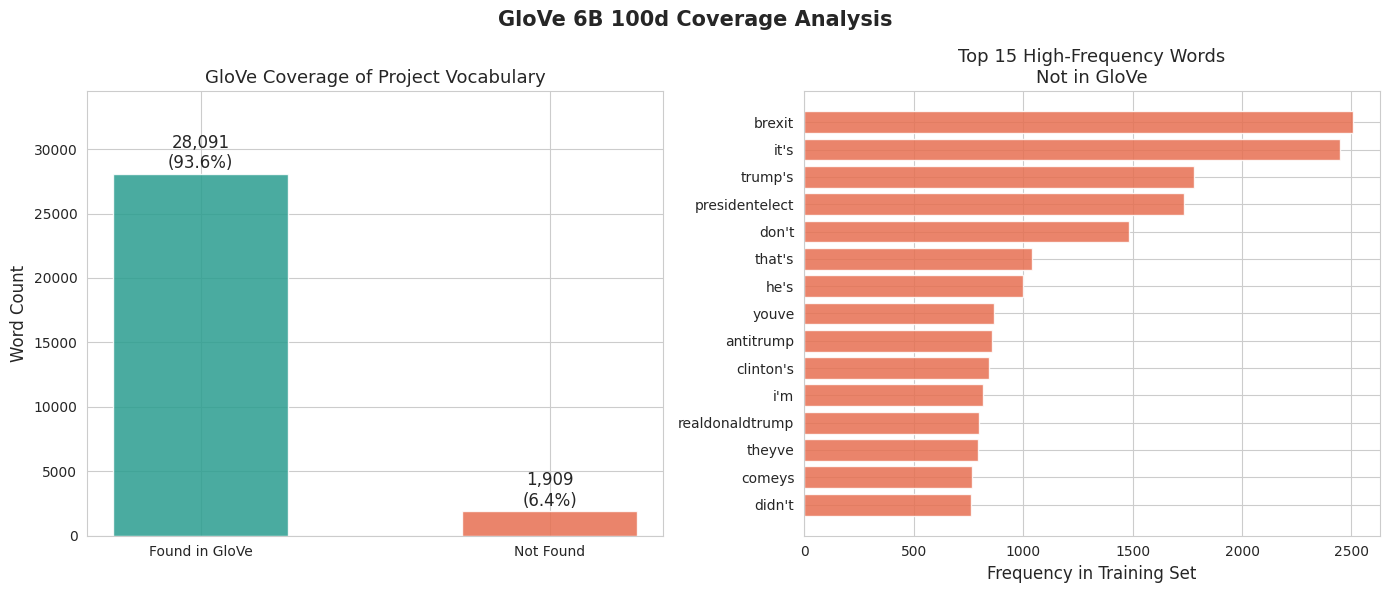

Saved: figures/features/18_glove_coverage.png


In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left: coverage bar chart
categories = ['Found in GloVe', 'Not Found']
counts     = [found, not_found]
colors     = ['#2A9D8F', '#E76F51']

bars = ax1.bar(categories, counts,
               color=colors, alpha=0.85, width=0.5)
for bar, count in zip(bars, counts):
    pct = count / VOCAB_SIZE * 100
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 100,
        f'{count:,}\n({pct:.1f}%)',
        ha='center', va='bottom', fontsize=12
    )
ax1.set_ylabel('Word Count', fontsize=12)
ax1.set_title('GloVe Coverage of Project Vocabulary',
              fontsize=13)
ax1.set_ylim(0, VOCAB_SIZE * 1.15)

# Right: top 15 uncovered words by frequency
top_missing = not_found_freq[:15]
words  = [w for w, _ in top_missing]
freqs  = [f for _, f in top_missing]

ax2.barh(range(len(words)), freqs[::-1],
         color='#E76F51', alpha=0.85)
ax2.set_yticks(range(len(words)))
ax2.set_yticklabels(words[::-1], fontsize=10)
ax2.set_xlabel('Frequency in Training Set', fontsize=12)
ax2.set_title('Top 15 High-Frequency Words\nNot in GloVe',
              fontsize=13)

fig.suptitle('GloVe 6B 100d Coverage Analysis',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR + '18_glove_coverage.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/features/18_glove_coverage.png")

## Section 9 -- Plot: Word Similarity Heatmap

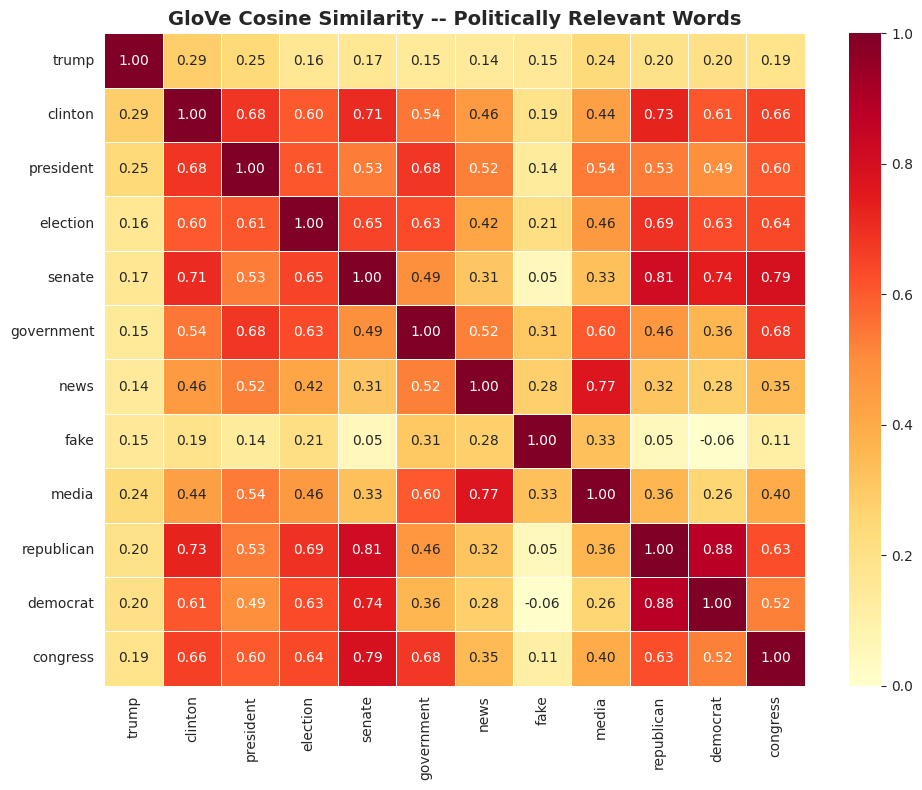

Saved: figures/features/19_glove_similarity_heatmap.png


In [9]:
# Select 12 politically relevant words present in GloVe
heatmap_words = [
    w for w in [
        'trump', 'clinton', 'president', 'election',
        'senate', 'government', 'news', 'fake',
        'media', 'republican', 'democrat', 'congress'
    ]
    if w in glove_vectors
]

# Build similarity matrix
vecs       = np.array([glove_vectors[w] for w in heatmap_words])
sim_matrix = cosine_similarity(vecs)
sim_df     = pd.DataFrame(
    sim_matrix,
    index=heatmap_words,
    columns=heatmap_words
)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    sim_df,
    annot=True, fmt='.2f',
    cmap='YlOrRd',
    vmin=0, vmax=1,
    ax=ax,
    linewidths=0.5
)
ax.set_title(
    'GloVe Cosine Similarity -- Politically Relevant Words',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.savefig(FIGURES_DIR + '19_glove_similarity_heatmap.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/features/19_glove_similarity_heatmap.png")

## Section 10 -- Summary

In [10]:
print_section("GLOVE FEATURES SUMMARY")

print("GloVe Configuration:")
print(f"  Source           : Stanford GloVe 6B")
print(f"  Dimensions       : {EMBEDDING_DIM}d")
print(f"  Total GloVe vocab: {len(glove_vectors):,}")
print()
print("Embedding Matrix:")
print(f"  Shape            : {embedding_matrix.shape}")
print(f"  Vocabulary size  : {VOCAB_SIZE:,}")
print(f"  Coverage         : {coverage_pct}%")
print(f"  Not covered      : {not_found:,} words")
print(f"  Unknown words    : random uniform [-0.05, 0.05]")
print(f"  PAD token (0)    : zero vector")
print()
print("Files saved to Google Drive:")
print(f"  models/glove_embedding_matrix.npy")
print(f"  figures/features/18_glove_coverage.png")
print(f"  figures/features/19_glove_similarity_heatmap.png")
print()
print("Next step: notebook 06 extracts linguistic features")
print("Both outputs feed into notebook 07 hybrid model.")

GLOVE FEATURES SUMMARY
GloVe Configuration:
  Source           : Stanford GloVe 6B
  Dimensions       : 100d
  Total GloVe vocab: 400,000

Embedding Matrix:
  Shape            : (30000, 100)
  Vocabulary size  : 30,000
  Coverage         : 93.64%
  Not covered      : 1,909 words
  Unknown words    : random uniform [-0.05, 0.05]
  PAD token (0)    : zero vector

Files saved to Google Drive:
  models/glove_embedding_matrix.npy
  figures/features/18_glove_coverage.png
  figures/features/19_glove_similarity_heatmap.png

Next step: notebook 06 extracts linguistic features
Both outputs feed into notebook 07 hybrid model.


## Next Steps

The GloVe embedding matrix is saved and ready for use
in notebook 07 (hybrid model). The matrix will be loaded
directly into the embedding layer of the GloVe + BiLSTM
branch, initialising it with pretrained semantic knowledge
instead of random vectors.

Notebook 06 extracts the 10 linguistic features that form
the third branch of the hybrid model.